# EDA 02 — Interim (preprocessed_from_raw) metadata file exploration

This notebook performs an exploratory analysis of the preprocessed raw metadata file after EDA_01 noteboook (file generated by *scripts/preprocess_data.py*).

The objective of this notebook is to explore the structure and content of the preprocessed metadata dataset. The analysis focuses on understanding the available candidate predictors for metadata-based machine learning models through descriptive statistics, missing value assessment, variable distributions, and basic exploratory analyses.

No feature engineering, feature selection, imputation, encoding, scaling, or other preprocessing steps are performed in this notebook.

In [ ]:
# Libraries + plot style

import pandas as pd
import sys
from subprocess import run

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project utilities
from skin_lesion_ai.utils.data_utils import (
    get_project_root,
    load_metadata_parquet,
)

# Custom plotting utilities
from skin_lesion_ai.visualisation.eda_plots import (
    set_eda_style,
    add_bar_labels,
    clean_axis_labels,
    apply_label_mapping,
    simplify_attribution_series,
    SEX_LABELS,
    SEX_PALETTE,
    ATTRIBUTION_PALETTE,
)

set_eda_style()
figures = {}

In [2]:
# Get latest 'preprocessed_from_raw' parquet file or generate it if it doesn't exist

repo_root = get_project_root()
script_path = repo_root / "scripts" / "preprocess_data.py"

try:
    df = load_metadata_parquet(
        stage="interim",
        filename="preprocessed_from_raw",
        timestamp_flag=True,
    )
except FileNotFoundError:
    run(
        [sys.executable, str(script_path)],
        cwd=str(repo_root),
        check=True,
    )
    df = load_metadata_parquet(
        stage="interim",
        filename="preprocessed_from_raw",
        timestamp_flag=True,
    )

In [3]:
# Preprocessed data

df

,isic_id,patient_id,attribution,copyright_license,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,tbp_lv_nevi_confidence,tbp_lv_dnn_lesion_confidence,tbp_lv_location,tbp_lv_location_simple,diagnostic_group
0,ISIC_0015670,IP_1235828,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,lower extremity,3.04,2.628592e-03,97.517282,Right Leg - Upper,Right Leg,benign_non_biopsied
1,ISIC_0015845,IP_8170065,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,head/neck,1.10,1.334303e-07,3.141455,Head & Neck,Head & Neck,benign_non_biopsied
2,ISIC_0015864,IP_6724798,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,posterior torso,3.40,2.959177e-04,99.804040,Torso Back Top Third,Torso Back,benign_non_biopsied
3,ISIC_0015902,IP_4111386,ACEMID MIA,CC-0,65.0,male,anterior torso,3.22,2.198945e+01,99.989998,Torso Front Top Half,Torso Front,benign_non_biopsied
4,ISIC_0024200,IP_8313778,Memorial Sloan Kettering Cancer Center,CC-BY,55.0,male,anterior torso,2.73,1.378832e-03,70.442510,Torso Front Top Half,Torso Front,benign_non_biopsied
...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,IP_1140263,"Department of Dermatology, Hospital Clínic de ...",CC-BY-NC,70.0,male,anterior torso,6.80,9.936233e+01,99.999988,Torso Front Top Half,Torso Front,benign_non_biopsied
401055,ISIC_9999951,IP_5678181,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,posterior torso,3.11,2.311562e-01,99.999820,Torso Back Top Third,Torso Back,benign_non_biopsied
401056,ISIC_9999960,IP_0076153,"Frazer Institute, The University of Queensland...",CC-BY,65.0,female,anterior torso,2.05,5.994798e+01,99.999416,Torso Front Top Half,Torso Front,benign_non_biopsied
401057,ISIC_9999964,IP_5231513,University Hospital of Basel,CC-BY-NC,30.0,female,anterior torso,2.80,9.931933e+01,100.000000,Torso Front Bottom Half,Torso Front,benign_non_biopsied


# SEX

### 1) BASIC DESCRIPTION

In [4]:
df["sex"].dtype

<StringDtype(na_value=nan)>

| Atributo                    | Valor                                              |
| --------------------------- | -------------------------------------------------- |
| Nombre de la variable       | `sex`                                              |
| Tipo de variable            | Cualitativa                                        |
| Subtipo                     | Binaria                                            |
| Tipo de almacenamiento      | `string`                                           |
| Valores observados          | `male`, `female`                                   |
| Presencia de *missing*      | Sí (`NA`)                                          |
| Nivel de observación        | Atributo del paciente almacenado a nivel de lesión |
| Codificación recomendada    | Binaria (`0/1`)                                    |


### 2) MISSING VALUES

In [5]:
# Missing sex analysis

# Lesion-level missing sex records
sex_missing_lesions = df.loc[df["sex"].isna()].copy()

# IDs of lesions and patients with missing sex
missing_sex_isic_ids = sex_missing_lesions["isic_id"].unique()
missing_sex_patient_ids = sex_missing_lesions["patient_id"].unique()

# Patient-level sex consistency
sex_per_patient = (
    df.groupby("patient_id")["sex"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_sex_values")
)

patients_with_inconsistent_sex = sex_per_patient.query("n_unique_sex_values > 1")

# Missingness at lesion level
lesion_missing_summary = pd.DataFrame(
    {
        "level": ["Lesion-level"],
        "total_records": [len(df)],
        "missing_sex_records": [df["sex"].isna().sum()],
        "missing_sex_percentage": [round(100 * df["sex"].isna().mean(), 2)],
    }
)

# Missingness at patient level
patient_sex_summary = (
    df.groupby("patient_id")["sex"]
    .agg(
        sex_values=lambda x: sorted(x.dropna().unique()),
        has_missing_sex=lambda x: x.isna().any(),
        all_missing_sex=lambda x: x.isna().all(),
        n_lesions="size",
    )
    .reset_index()
)

patients_with_missing_sex = patient_sex_summary.query("has_missing_sex == True").copy()

patient_missing_summary = pd.DataFrame(
    {
        "level": ["Patient-level"],
        "total_records": [df["patient_id"].nunique()],
        "missing_sex_records": [patients_with_missing_sex["patient_id"].nunique()],
        "missing_sex_percentage": [
            round(
                100
                * patients_with_missing_sex["patient_id"].nunique()
                / df["patient_id"].nunique(),
                2,
            )
        ],
    }
)

# Combined summary
sex_missing_summary = pd.concat(
    [lesion_missing_summary, patient_missing_summary], ignore_index=True
)

sex_missing_summary

,level,total_records,missing_sex_records,missing_sex_percentage
0,Lesion-level,401059,11517,2.87
1,Patient-level,1042,33,3.17


| Nivel de análisis            |                  Total |       Registros con `sex` missing | % missing | Comentario                                                  |
| ---------------------------- | ---------------------: | --------------------------------: | --------: | ----------------------------------------------------------- |
| Lesión                       |                401,059 |                            11,517 |     2.88% | Corresponde a lesiones sin información de sexo del paciente |
| Paciente                     |                  1,042 |                                33 |     3.17% | Corresponde a pacientes sin sexo registrado                 |
| Consistencia paciente-lesión | 33 pacientes afectados | 33 con todas sus lesiones missing |   100.00% | La ausencia de `sex` es consistente dentro de cada paciente |

La variable `sex` presenta valores *missing* en 11,517 lesiones, equivalentes al 2.88% del total de registros a nivel de lesión. A nivel de paciente, estos valores corresponden a 33 pacientes de un total de 1,042, lo que representa un 3.17%.

Dado que `sex` es una característica propia del paciente y no de la lesión, se evaluó la consistencia de la ausencia de información dentro de cada paciente. En todos los pacientes afectados, la variable `sex` aparece como missing en todas sus lesiones, sin observarse casos de ausencia parcial. Por tanto, el patrón de missingness es coherente con la naturaleza patient-level de la variable.


### 3) SEX AND CLASSIFCATION

In [ ]:
# Sex summary table


# Lesion-level counts
lesion_counts = df.groupby("sex", dropna=False).size().rename("n_lesions")

# Patient-level counts
patient_counts = (
    df.groupby("sex", dropna=False)["patient_id"].nunique().rename("n_patients")
)

# Diagnostic group counts
diagnostic_counts = pd.crosstab(df["sex"].fillna("Missing"), df["diagnostic_group"])

# Main table
sex_summary = pd.concat(
    [
        lesion_counts.rename_axis("sex"),
        patient_counts,
    ],
    axis=1,
).reset_index()

# Replace missing label
sex_summary["sex"] = sex_summary["sex"].fillna("Missing")

# Lesion and patient percentages
sex_summary["pct_lesions"] = round(
    100 * sex_summary["n_lesions"] / len(df),
    2,
)

sex_summary["pct_patients"] = round(
    100 * sex_summary["n_patients"] / df["patient_id"].nunique(),
    2,
)

# Merge diagnostic counts
sex_summary = sex_summary.merge(
    diagnostic_counts.reset_index(),
    on="sex",
    how="left",
)

# All biopsied
sex_summary["all_biopsied"] = (
    sex_summary["benign_biopsied"]
    + sex_summary["malignant_biopsied"]
    + sex_summary["indeterminate_biopsied"]
)

# Percentages within sex
diagnostic_cols = [
    "benign_non_biopsied",
    "benign_biopsied",
    "malignant_biopsied",
    "indeterminate_biopsied",
    "all_biopsied",
]

for col in diagnostic_cols:
    sex_summary[f"pct_{col}"] = round(
        100 * sex_summary[col] / sex_summary["n_lesions"],
        2,
    )

# Total row
total_row = {
    "sex": "Total",
    "n_lesions": len(df),
    "pct_lesions": 100.0,
    "n_patients": df["patient_id"].nunique(),
    "pct_patients": 100.0,
    "benign_non_biopsied": (df["diagnostic_group"] == "benign_non_biopsied").sum(),
    "benign_biopsied": (df["diagnostic_group"] == "benign_biopsied").sum(),
    "malignant_biopsied": (df["diagnostic_group"] == "malignant_biopsied").sum(),
    "indeterminate_biopsied": (
        df["diagnostic_group"] == "indeterminate_biopsied"
    ).sum(),
}

total_row["all_biopsied"] = (
    total_row["benign_biopsied"]
    + total_row["malignant_biopsied"]
    + total_row["indeterminate_biopsied"]
)

for col in diagnostic_cols:
    total_row[f"pct_{col}"] = round(
        100 * total_row[col] / total_row["n_lesions"],
        2,
    )

sex_summary = pd.concat(
    [sex_summary, pd.DataFrame([total_row])],
    ignore_index=True,
)

sex_summary

       sex  n_lesions  n_patients  pct_lesions  pct_patients  benign_biopsied  \
0   female     123996         458        30.92         43.95              238   
1     male     265546         551        66.21         52.88              306   
2  Missing      11517          33         2.87          3.17               17   
3    Total     401059        1042       100.00        100.00              561   

   benign_non_biopsied  indeterminate_biopsied  malignant_biopsied  \
0               123596                      53                 109   
1               264910                      56                 274   
2                11485                       5                  10   
3               399991                     114                 393   

   all_biopsied  pct_benign_non_biopsied  pct_benign_biopsied  \
0           400                    99.68                 0.19   
1           636                    99.76                 0.12   
2            32                    99.72        

To evaluate the potential predictive value of `sex`, its distribution was examined across the different diagnostic groups. As the project considers two potential classification tasks:

1. **Biopsy recommendation model**: predicting whether a lesion should be biopsied (`biopsied` vs `non-biopsied`).
2. **Malignancy model**: predicting whether a biopsied lesion is malignant (`malignant` vs `non-malignant`).

the relationship between `sex` and both classification targets was explored.

For categorical variables, association can be assessed using contingency tables and the Chi-square test of independence. However, given the very large sample size, statistical significance alone is not informative, as even negligible differences may produce extremely small p-values.

Therefore, the main quantity of interest is **Cramér's V**, which measures the strength of association between two categorical variables independently of sample size.

Interpretation guideline:

| Cramér's V | Interpretation |
|------------|---------------|
| < 0.10 | Very weak association |
| 0.10 – 0.30 | Weak association |
| 0.30 – 0.50 | Moderate association |
| > 0.50 | Strong association |

The following analyses evaluate whether `sex` contains information that may be useful for either classification task.

**Model 1: Biopsy vs non-biopsy**

In [7]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

# Binary target for biopsy recommendation
df["biopsied"] = df["diagnostic_group"] != "benign_non_biopsied"

# Contingency table
sex_vs_biopsy = pd.crosstab(df["sex"].fillna("Missing"), df["biopsied"])

sex_vs_biopsy

biopsied,False,True
sex,,
Missing,11485,32
female,123596,400
male,264910,636


In [ ]:
# Row percentages
sex_vs_biopsy_pct = round(
    100
    * pd.crosstab(
        df["sex"].fillna("Missing"),
        df["biopsied"],
        normalize="index",
    ),
    2,
)

sex_vs_biopsy_pct

biopsied  False  True 
sex                   
Missing   99.72   0.28
female    99.68   0.32
male      99.76   0.24


In [9]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(sex_vs_biopsy)

# Cramer's V
cramers_v_biopsy = association(
    sex_vs_biopsy,
    method="cramer",
)

print(f"Chi-square p-value: {p_value:.4e}")
print(f"Cramer's V: {cramers_v_biopsy:.4f}")

Chi-square p-value: 1.6457e-05
Cramer's V: 0.0074


Although the association between sex and biopsy status is statistically significant (χ² test, p < 0.001), the effect size is negligible (Cramér's V = 0.007), suggesting that patient sex provides very limited predictive information for distinguishing biopsied from non-biopsied lesions.

**Model 2: Malignant vs non-malignant among biopsied lesions**

In [10]:
# Only biopsied lesions
df_biopsied = df.loc[df["diagnostic_group"] != "benign_non_biopsied"].copy()

# Binary target for malignancy prediction
df_biopsied["malignant"] = df_biopsied["diagnostic_group"] == "malignant_biopsied"

# Contingency table
sex_vs_malignancy = pd.crosstab(
    df_biopsied["sex"].fillna("Missing"), df_biopsied["malignant"]
)

sex_vs_malignancy

malignant,False,True
sex,,
Missing,22,10
female,291,109
male,362,274


In [ ]:
# Row percentages
sex_vs_malignancy_pct = round(
    100
    * pd.crosstab(
        df_biopsied["sex"].fillna("Missing"),
        df_biopsied["malignant"],
        normalize="index",
    ),
    2,
)

sex_vs_malignancy_pct

malignant  False  True 
sex                    
Missing    68.75  31.25
female     72.75  27.25
male       56.92  43.08


In [12]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(sex_vs_malignancy)

# Cramer's V
cramers_v_malignancy = association(
    sex_vs_malignancy,
    method="cramer",
)

print(f"Chi-square p-value: {p_value:.4e}")
print(f"Cramer's V: {cramers_v_malignancy:.4f}")

Chi-square p-value: 1.4406e-06
Cramer's V: 0.1587


The association between sex and malignancy status among biopsied lesions is statistically significant (χ² test, p < 0.001) and shows a weak but meaningful effect size (Cramér's V = 0.159). This suggests that patient sex may provide useful predictive information when distinguishing malignant from non-malignant biopsied lesions.

#### Sexo y clasificación

El potencial valor predictivo de la variable `sex` se evaluó analizando su asociación con las dos tareas de clasificación consideradas en este proyecto:

1. **Modelo de recomendación de biopsia:** clasificación de lesiones como biopsiadas o no biopsiadas.
2. **Modelo de malignidad:** clasificación de lesiones biopsiadas como malignas o no malignas (agrupando las lesiones benignas e indeterminadas en una única categoría).

#### Distribución de los grupos diagnósticos según el sexo

| Sexo | Lesiones (n) | Pacientes (n) | No biopsiadas (%) | Benignas biopsiadas (%) | Indeterminadas biopsiadas (%) | Malignas biopsiadas (%) | Total biopsiadas (%) |
|------|-------------:|--------------:|------------------:|------------------------:|------------------------------:|------------------------:|---------------------:|
| Female | 123,996 | 458 | 99.68 | 0.19 | 0.04 | 0.09 | 0.32 |
| Male | 265,546 | 551 | 99.76 | 0.12 | 0.02 | 0.10 | 0.24 |
| Missing | 11,517 | 33 | 99.72 | 0.15 | 0.04 | 0.09 | 0.28 |
| **Total** | **401,059** | **1,042** | **99.73** | **0.14** | **0.03** | **0.10** | **0.27** |

#### Evaluación estadística de la asociación

La asociación entre `sex` y cada una de las variables objetivo se evaluó mediante el **test Chi-cuadrado de independencia**.

Este test permite determinar si la distribución de la variable objetivo difiere significativamente entre las categorías de sexo. No obstante, dado el gran tamaño muestral disponible (>400.000 lesiones), incluso diferencias muy pequeñas pueden producir valores de p extremadamente bajos. Por este motivo, la significación estadística por sí sola no resulta suficiente para valorar la relevancia práctica de la asociación observada.

Para cuantificar la magnitud real de la asociación se utilizó **V de Cramér**, una medida basada en el estadístico Chi-cuadrado y acotada entre 0 y 1:

| V de Cramér | Interpretación |
|------------|---------------|
| < 0.10 | Asociación muy débil |
| 0.10 – 0.30 | Asociación débil |
| 0.30 – 0.50 | Asociación moderada |
| > 0.50 | Asociación fuerte |

A diferencia del p-valor, V de Cramér permite evaluar si una asociación es potencialmente relevante desde el punto de vista predictivo.

#### Resultados: modelo de recomendación de biopsia

Para la clasificación de lesiones biopsiadas frente a no biopsiadas se obtuvo:

- Chi-cuadrado: p < 0.001
- V de Cramér = 0.007

Aunque la asociación resulta estadísticamente significativa, el tamaño del efecto es prácticamente nulo. Las proporciones de lesiones biopsiadas son muy similares entre hombres (0.24%), mujeres (0.32%) y registros con sexo desconocido (0.28%).

Por tanto, la variable `sex` aporta una capacidad discriminativa muy limitada para predecir si una lesión será biopsiada y no parece constituir un predictor relevante para este modelo.

#### Resultados: modelo de malignidad

Para la clasificación de lesiones malignas frente a no malignas dentro del subconjunto de lesiones biopsiadas se obtuvo:

- Chi-cuadrado: p < 0.001
- V de Cramér = 0.159

En este caso se observa una asociación significativamente más intensa. Entre las lesiones biopsiadas, la proporción de malignidad es del 43.08% en hombres frente al 27.25% en mujeres.

Aunque la magnitud de la asociación sigue siendo moderada-baja, el valor de V de Cramér indica que el sexo contiene información potencialmente útil para la predicción de malignidad.

En consecuencia, `sex` parece tener un interés predictivo limitado para el modelo de recomendación de biopsia, pero podría constituir una variable relevante en modelos destinados a distinguir lesiones malignas de no malignas entre aquellas que ya han sido biopsiadas. Asimismo, dado que la literatura médica ha descrito diferencias en la distribución anatómica de las lesiones cutáneas entre hombres y mujeres, no puede descartarse que parte de su utilidad predictiva se manifieste de forma indirecta mediante su relación con la localización anatómica.

### 4) TYPE OF MISSINGNESS

Before deciding how to handle the missing values of `sex`, it is important to investigate the potential missingness mechanism.

In practice, missing values may occur completely at random (MCAR), depend on other observed variables (MAR), or depend on unobserved factors (MNAR). Although it is generally not possible to determine the exact mechanism from the available data alone, exploratory analyses can provide evidence supporting one mechanism over another.

To better understand the origin of the missing values in `sex`, the following aspects were evaluated:

1. **Data source (`attribution`)**, to determine whether missing values are concentrated in specific datasets or collection centres.
2. **Age distribution**, to assess whether patients with missing sex information differ systematically from the rest of the cohort.
3. **Diagnostic group distribution**, to evaluate whether missingness is associated with lesion outcome or diagnostic category.

These analyses help determine whether the observed missing values are compatible with a random recording issue or whether they may introduce systematic bias into subsequent modelling.

In [17]:
sex_missing_by_attribution = df.groupby("attribution")["sex"].agg(
    total="size",
    missing=lambda x: x.isna().sum(),
)

sex_missing_by_attribution["pct_missing"] = round(
    100 * sex_missing_by_attribution["missing"] / sex_missing_by_attribution["total"],
    2,
)

sex_missing_by_attribution.sort_values(
    "pct_missing",
    ascending=False,
)

print(sex_missing_by_attribution)

                                                     total  missing  \
attribution                                                           
ACEMID MIA                                           28665        0   
Department of Dermatology, Hospital Clínic de B...  105724      454   
Department of Dermatology, University of Athens...    7976        0   
Frazer Institute, The University of Queensland,...   51768     2319   
Memorial Sloan Kettering Cancer Center              129068        0   
University Hospital of Basel                         65218     8744   
ViDIR Group, Department of Dermatology, Medical...   12640        0   

                                                    pct_missing  
attribution                                                      
ACEMID MIA                                                 0.00  
Department of Dermatology, Hospital Clínic de B...         0.43  
Department of Dermatology, University of Athens...         0.00  
Frazer Institute, The Universi

In [20]:
attribution_patient_missing = (
    df.groupby(["attribution", "patient_id"])["sex"]
    .apply(lambda x: x.isna().all())
    .reset_index(name="sex_missing")
)

attribution_patient_summary = attribution_patient_missing.groupby("attribution").agg(
    n_patients=("patient_id", "nunique"),
    missing_patients=("sex_missing", "sum"),
)

attribution_patient_summary["pct_missing_patients"] = round(
    100
    * attribution_patient_summary["missing_patients"]
    / attribution_patient_summary["n_patients"],
    2,
)

attribution_patient_summary.sort_values(
    "pct_missing_patients",
    ascending=False,
)

print(attribution_patient_summary)

                                                    n_patients  \
attribution                                                      
ACEMID MIA                                                  44   
Department of Dermatology, Hospital Clínic de B...         163   
Department of Dermatology, University of Athens...          16   
Frazer Institute, The University of Queensland,...         176   
Memorial Sloan Kettering Cancer Center                     398   
University Hospital of Basel                               230   
ViDIR Group, Department of Dermatology, Medical...          15   

                                                    missing_patients  \
attribution                                                            
ACEMID MIA                                                         0   
Department of Dermatology, Hospital Clínic de B...                 1   
Department of Dermatology, University of Athens...                 0   
Frazer Institute, The University of Queenslan

In [18]:
sex_missing_age_summary = df.groupby(df["sex"].isna())["age_approx"].describe()

print(sex_missing_age_summary)

          count       mean        std   min   25%   50%   75%   max
sex                                                                
False  387655.0  58.060853  13.669418   5.0  50.0  60.0  70.0  85.0
True    10606.0  56.263436  10.426863  15.0  55.0  55.0  65.0  75.0


In [19]:
sex_missing_diagnostic = round(
    100
    * pd.crosstab(
        df["sex"].isna(),
        df["diagnostic_group"],
        normalize="index",
    ),
    2,
)

print(sex_missing_diagnostic)

diagnostic_group  benign_biopsied  benign_non_biopsied  \
sex                                                      
False                        0.14                99.73   
True                         0.15                99.72   

diagnostic_group  indeterminate_biopsied  malignant_biopsied  
sex                                                           
False                               0.03                0.10  
True                                0.04                0.09  


In [24]:
patients_to_remove = df.loc[df["sex"].isna(), "patient_id"].unique()

df_without_missing_sex = df.loc[~df["patient_id"].isin(patients_to_remove)].copy()

# Distribution before removal
before = 100 * df["diagnostic_group"].value_counts(normalize=True).sort_index()

# Distribution after removal
after = (
    100
    * df_without_missing_sex["diagnostic_group"]
    .value_counts(normalize=True)
    .sort_index()
)

comparison = pd.concat(
    [before, after],
    axis=1,
)

comparison.columns = [
    "Before removal (%)",
    "After removal (%)",
]

# Difference in percentage points
comparison["Difference (pp)"] = (
    comparison["After removal (%)"] - comparison["Before removal (%)"]
)

# Display formatting
comparison = comparison.round(
    {
        "Before removal (%)": 4,
        "After removal (%)": 4,
        "Difference (pp)": 6,
    }
)

print(comparison)

                        Before removal (%)  After removal (%)  Difference (pp)
diagnostic_group                                                              
benign_biopsied                     0.1399             0.1397        -0.000228
benign_non_biopsied                99.7337             99.734         0.000342
indeterminate_biopsied              0.0284              0.028        -0.000443
malignant_biopsied                   0.098             0.0983          0.00033


In [25]:
max_difference = comparison["Difference (pp)"].abs().max()

print(f"Maximum absolute difference: {max_difference:.6f} percentage points")

Maximum absolute difference: 0.000443 percentage points


In [22]:
print(patients_to_remove)

<ArrowStringArray>
['IP_3371534', 'IP_6187331', 'IP_9472195', 'IP_2914511', 'IP_5044083',
 'IP_6207479', 'IP_6975913', 'IP_1241473', 'IP_5887935', 'IP_8810058',
 'IP_8999199', 'IP_6732258', 'IP_6413837', 'IP_1474479', 'IP_0797650',
 'IP_2148283', 'IP_4579352', 'IP_7563441', 'IP_1715157', 'IP_1016097',
 'IP_7703522', 'IP_4080836', 'IP_8377208', 'IP_1822913', 'IP_6193088',
 'IP_0473747', 'IP_1433033', 'IP_6709102', 'IP_8036435', 'IP_2075317',
 'IP_7858959', 'IP_9550509', 'IP_5373245']
Length: 33, dtype: str


#### Conclusión sobre los valores missing de `sex`

Los análisis realizados muestran que la ausencia de información en la variable `sex` no se distribuye de forma homogénea entre las distintas fuentes de datos. Aunque algunos centros no presentan ningún valor ausente, la mayoría de los pacientes afectados se concentran en un número reducido de contribuyentes, especialmente en el *University Hospital of Basel*, donde el 11.74% de los pacientes carecen de información sobre el sexo, y en menor medida en el *Frazer Institute (The University of Queensland)*, con un 2.84%.

Asimismo, los pacientes con valores missing presentan una distribución diagnóstica prácticamente idéntica a la observada en el resto de la cohorte. Del mismo modo, aunque la edad mediana es ligeramente inferior en los registros con sexo desconocido, las distribuciones de edad son globalmente comparables y no sugieren la existencia de diferencias clínicas relevantes.

Estos resultados indican que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida o registro de datos de determinados centros, más que con características propias de los pacientes o de las lesiones. En consecuencia, el patrón observado parece más compatible con un mecanismo **Missing At Random (MAR)** asociado principalmente a la variable `attribution` que con un mecanismo **Missing Not At Random (MNAR)**.

En total, únicamente 33 pacientes (3.17% de la cohorte) presentan valores missing en la variable `sex`, lo que afecta a 11,517 lesiones (2.87% del conjunto de datos). Para evaluar el posible impacto de su exclusión, se comparó tanto la composición general del dataset como la distribución de las categorías diagnósticas antes y después de eliminar dichos pacientes.

#### Impacto sobre el tamaño de la cohorte

| Escenario                                 | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ----------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                          |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con `sex` missing |         1,009 |         96.83 |      389,542 |        97.13 |
| Registros eliminados                      |            33 |          3.17 |       11,517 |         2.87 |

#### Impacto sobre la distribución de las etiquetas diagnósticas

| Categoría diagnóstica  | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | ---------------: |
| Benign biopsied        |    0.1399 |      0.1397 |        -0.000228 |
| Benign non-biopsied    |   99.7337 |     99.7340 |         0.000342 |
| Indeterminate biopsied |    0.0284 |      0.0280 |        -0.000443 |
| Malignant biopsied     |    0.0980 |      0.0983 |         0.000330 |

Como puede observarse, la eliminación de los pacientes con valores missing en `sex` no produce ninguna modificación apreciable en la distribución de las categorías diagnósticas. La diferencia absoluta máxima observada es de únicamente **0.000443 puntos porcentuales**, correspondiente a la categoría `indeterminate_biopsied`. En el caso de las lesiones malignas biopsiadas, la proporción pasa de 0.0980% a 0.0983%, una variación de solo 0.000330 puntos porcentuales.

Por tanto, la exclusión de estos registros no introduce un incremento relevante del desbalanceo de las variables objetivo ni altera la composición clínica del conjunto de datos.

Dado el reducido número de pacientes afectados, la ausencia de evidencia de sesgos clínicamente relevantes, la concentración de los valores missing en un número limitado de centros y el impacto prácticamente nulo sobre la distribución de las etiquetas diagnósticas, se recomienda excluir estos 33 pacientes de los análisis posteriores. Esta decisión simplifica el preprocesamiento de la variable `sex`, evita la creación de una categoría artificial (`Unknown`) con escasa representación y permite trabajar con una cohorte homogénea sin pérdida apreciable de información.

Por motivos de reproducibilidad y trazabilidad, los 33 pacientes excluidos del análisis corresponden a los siguientes identificadores:

`IP_3371534`, `IP_6187331`, `IP_9472195`, `IP_2914511`, `IP_5044083`, `IP_6207479`, `IP_6975913`, `IP_1241473`, `IP_5887935`, `IP_8810058`, `IP_8999199`, `IP_6732258`, `IP_6413837`, `IP_1474479`, `IP_0797650`, `IP_2148283`, `IP_4579352`, `IP_7563441`, `IP_1715157`, `IP_1016097`, `IP_7703522`, `IP_4080836`, `IP_8377208`, `IP_1822913`, `IP_6193088`, `IP_0473747`, `IP_1433033`, `IP_6709102`, `IP_8036435`, `IP_2075317`, `IP_7858959`, `IP_9550509` e `IP_5373245`.


### 5) FINAL SEX PLOTS AND TABLES

#### Predictive value of sex

In [46]:
fig_sex = []

In [41]:
# Plot data: predictive value of sex

biopsy_plot_df = sex_vs_biopsy_pct[True].rename("biopsied_pct").reset_index()

malignancy_plot_df = sex_vs_malignancy_pct[True].rename("malignant_pct").reset_index()

n_plot_df = sex_summary.loc[sex_summary["sex"] != "Total", ["sex", "n_lesions"]]

sex_predictive_plot_df = biopsy_plot_df.merge(malignancy_plot_df, on="sex").merge(
    n_plot_df, on="sex"
)

sex_predictive_plot_df["sex"] = apply_label_mapping(
    sex_predictive_plot_df["sex"],
    SEX_LABELS,
)

sex_predictive_plot_df["sex_display"] = (
    sex_predictive_plot_df["sex"]
    + "\n(n="
    + sex_predictive_plot_df["n_lesions"].map(lambda x: f"{x:,}")
    + ")"
)

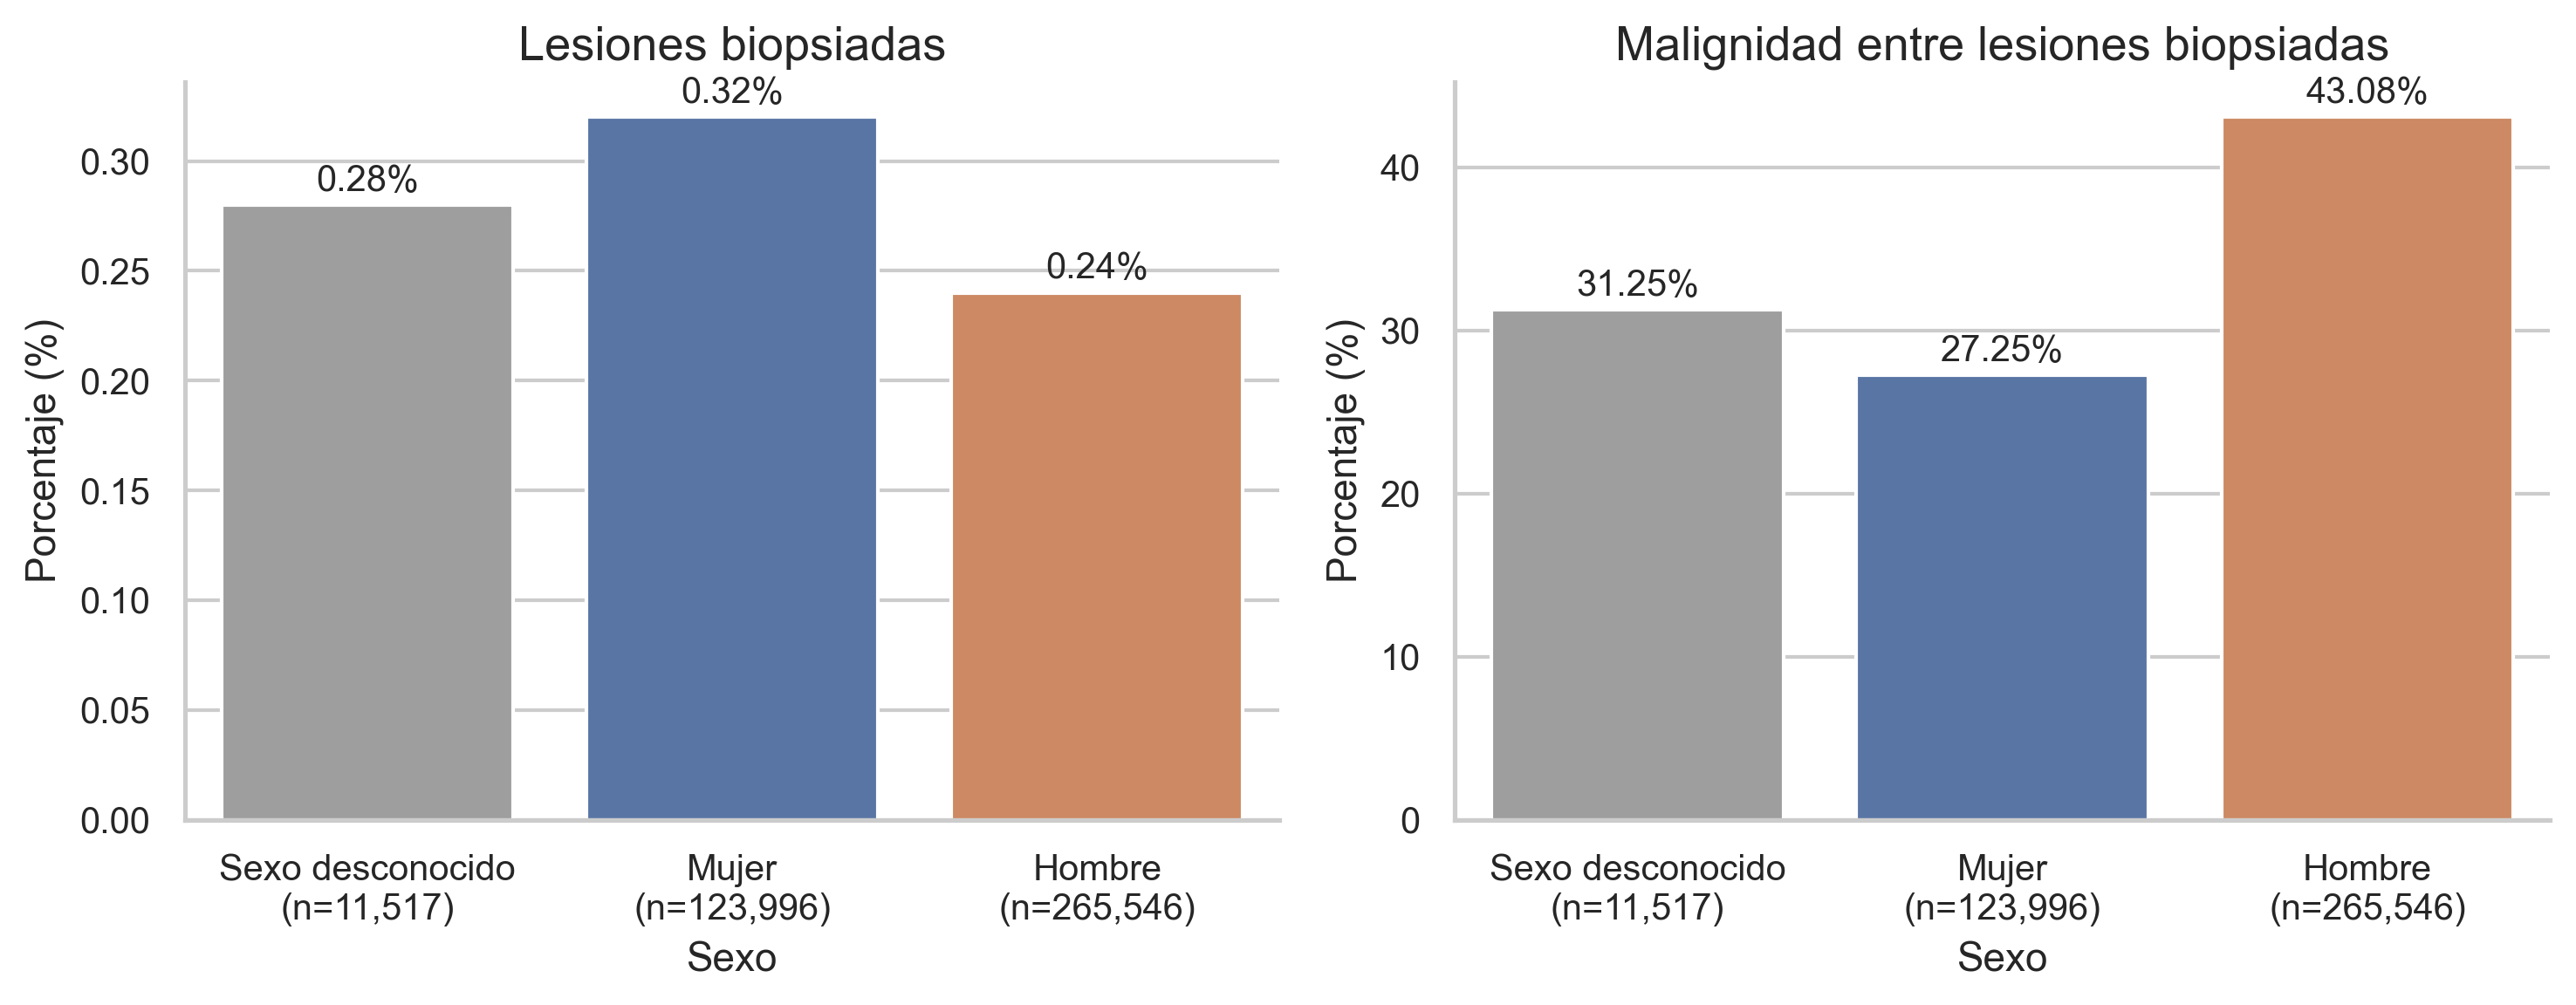

In [78]:
# Predictive value of sex

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

# Biopsy rate
sns.barplot(
    data=sex_predictive_plot_df,
    x="sex_display",
    y="biopsied_pct",
    hue="sex",
    palette=SEX_PALETTE,
    legend=False,
    ax=axes[0],
)

add_bar_labels(
    axes[0],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[0],
    xlabel="Sexo",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

# Malignancy rate among biopsied lesions
sns.barplot(
    data=sex_predictive_plot_df,
    x="sex_display",
    y="malignant_pct",
    hue="sex",
    palette=SEX_PALETTE,
    legend=False,
    ax=axes[1],
)

add_bar_labels(
    axes[1],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[1],
    xlabel="Sexo",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

plt.tight_layout()
plt.show()

figures["sex_predictive_value"] = fig

In [ ]:
# save_plot(
#     figures["sex_predictive_value"],
#     name="sex_predictive_value_biopsy_and_malignancy",
#     subfolder="EDA",
# )

#### Missing sex by attribution

In [70]:
# Plot data: missing sex by attribution

sex_missing_attribution_plot_df = attribution_patient_summary.reset_index().copy()

sex_missing_attribution_plot_df["attribution_label"] = simplify_attribution_series(
    sex_missing_attribution_plot_df["attribution"]
)

sex_missing_attribution_plot_df["label"] = (
    sex_missing_attribution_plot_df["pct_missing_patients"].map("{:.2f}%".format)
    + " ("
    + sex_missing_attribution_plot_df["missing_patients"].astype(int).astype(str)
    + "/"
    + sex_missing_attribution_plot_df["n_patients"].astype(int).astype(str)
    + ")"
)

sex_missing_attribution_plot_df = sex_missing_attribution_plot_df.sort_values(
    "pct_missing_patients",
    ascending=True,
)

attribution_legend = (
    sex_missing_attribution_plot_df[["attribution_label", "attribution"]]
    .drop_duplicates()
    .sort_values("attribution_label")
)

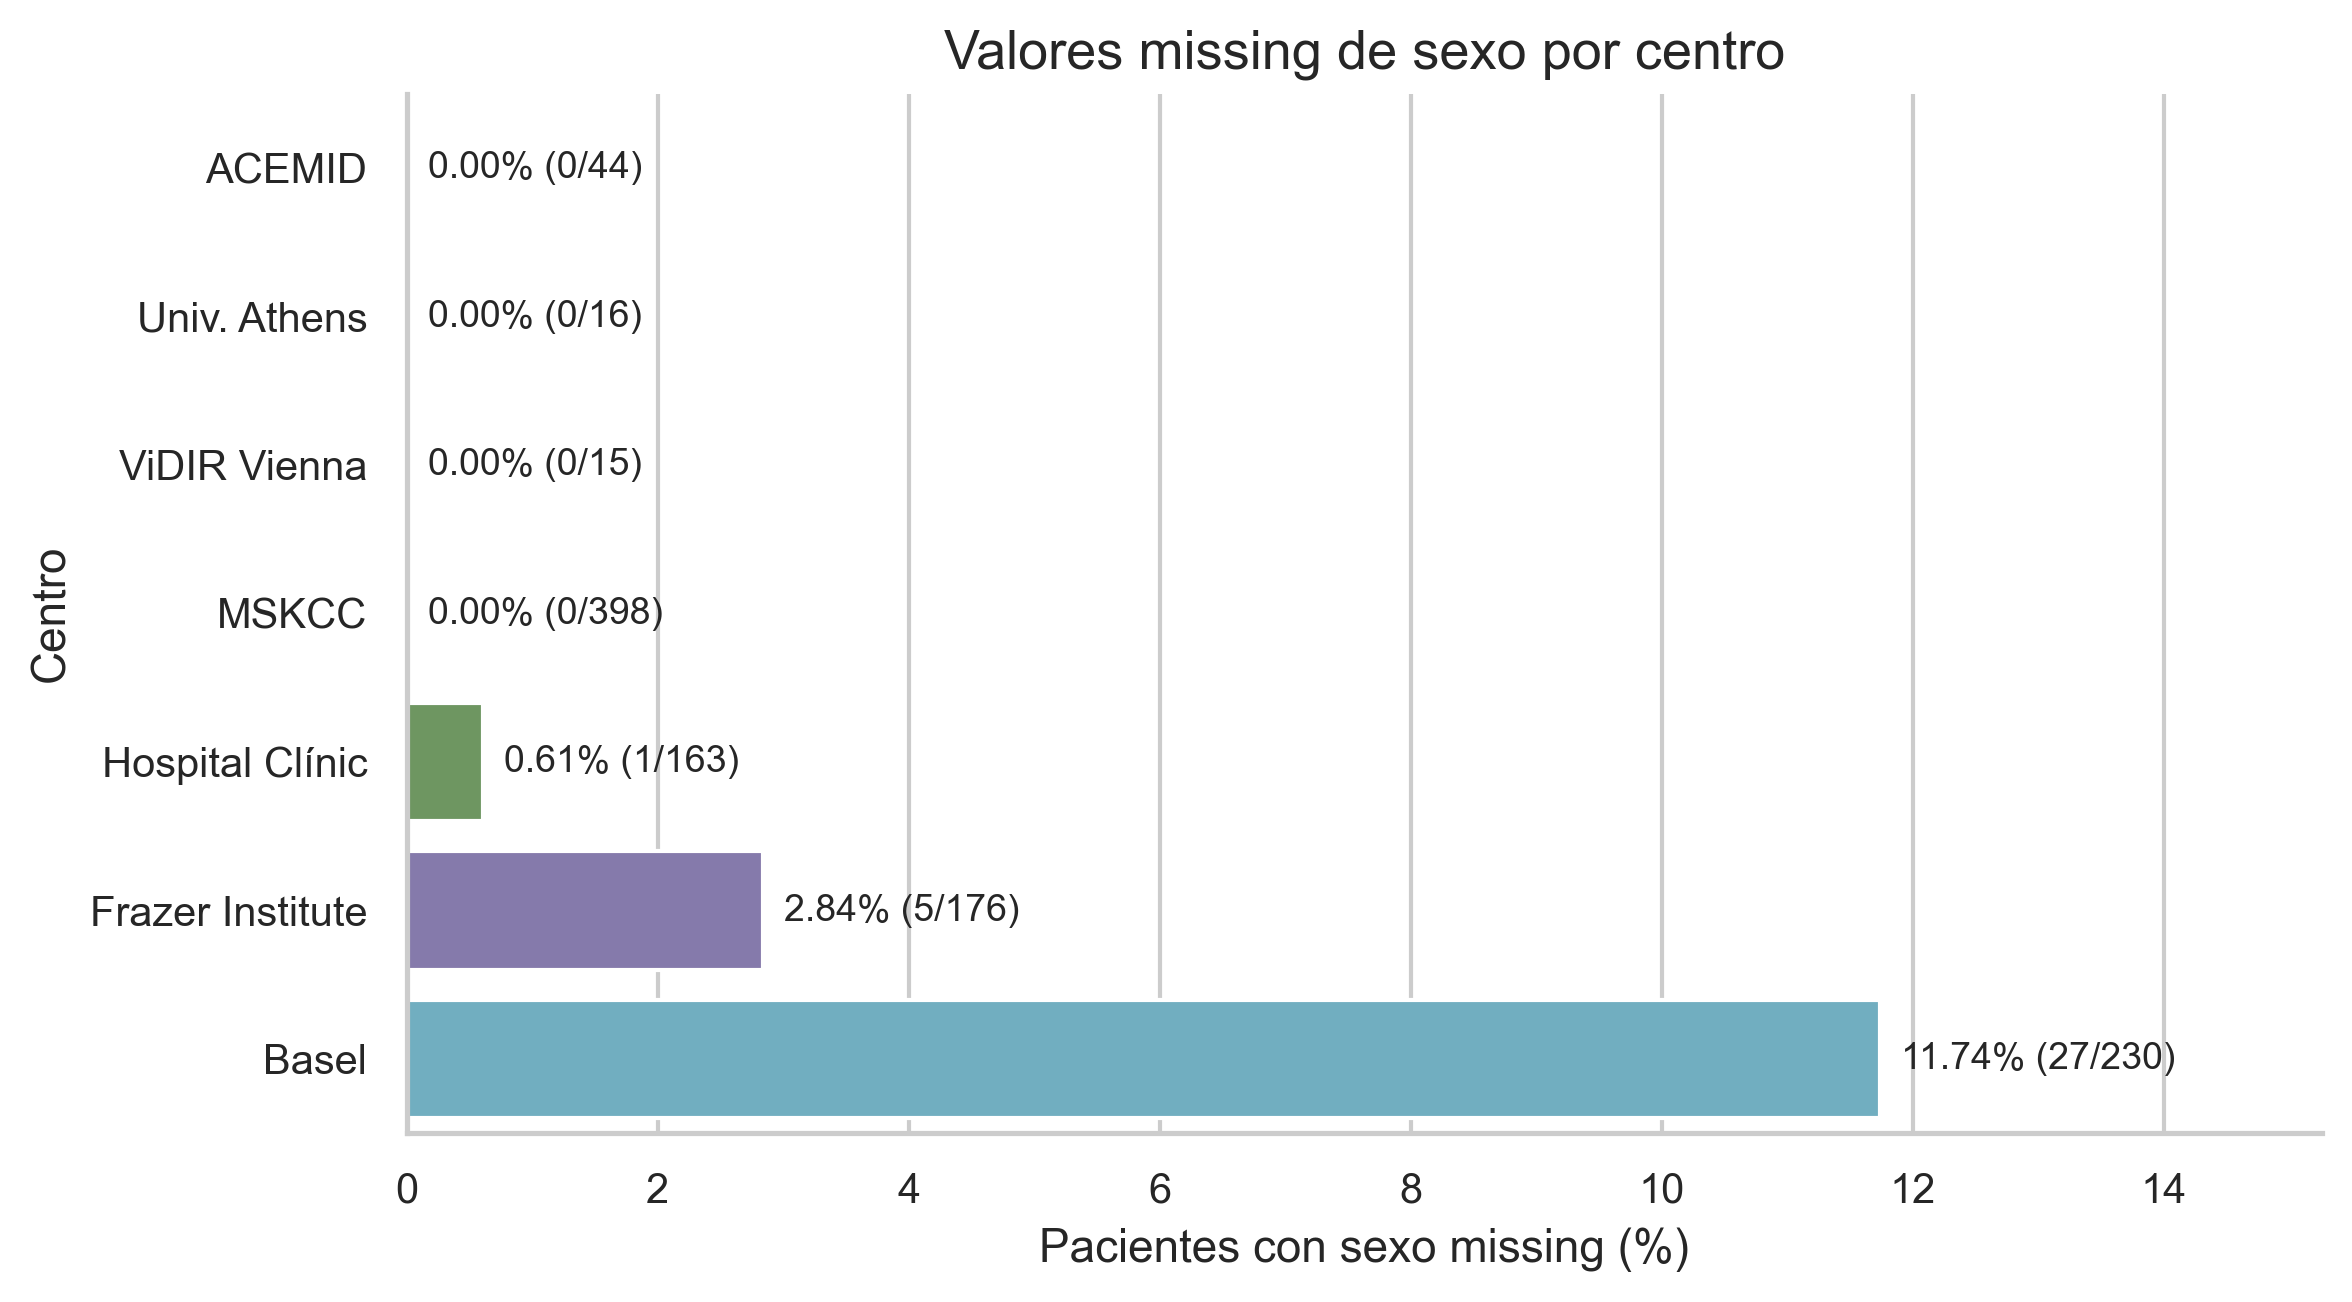

In [75]:
# Missing sex by attribution

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=sex_missing_attribution_plot_df,
    x="pct_missing_patients",
    y="attribution_label",
    hue="attribution_label",
    palette=ATTRIBUTION_PALETTE,
    legend=False,
    ax=ax,
)

# Add percentage and count labels
for patch, (_, row) in zip(
    ax.patches,
    sex_missing_attribution_plot_df.iterrows(),
):
    width = patch.get_width()

    ax.annotate(
        row["label"],
        xy=(
            width,
            patch.get_y() + patch.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

clean_axis_labels(
    ax,
    xlabel="Pacientes con sexo missing (%)",
    ylabel="Centro",
    title="Valores missing de sexo por centro",
)

ax.set_xlim(
    0,
    sex_missing_attribution_plot_df["pct_missing_patients"].max() * 1.30,
)

plt.tight_layout()
plt.show()

figures["sex_missing_attribution"] = fig

# AGE

### 1) BASIC DESCRIPTION

# ANATOMICAL SITE

# LESION SIZE

# FINAL SUMMARY

## Variable 'sex'

La variable `sex` representa el sexo biológico del paciente. Se trata de una variable cualitativa binaria, almacenada en formato `string` y registrada a nivel de lesión, aunque conceptualmente corresponde a un atributo de nivel paciente. El conjunto de datos contiene **401,059 lesiones** correspondientes a **1,042 pacientes**.

La variable presenta dos categorías observadas (`female` y `male`) además de un pequeño porcentaje de valores missing. La distribución muestra un predominio masculino tanto a nivel de lesión como de paciente.

| Sexo      | Lesiones (n) | % lesiones | Pacientes (n) | % pacientes | Lesiones biopsiadas (n) | % biopsiadas | Lesiones malignas (n)            | % malignas entre biopsiadas |
| --------- | -----------: | ---------: | ------------: | ----------: | ----------------------: | -----------: | -------------------------------: | --------------------------: |
| female    |      123,996 |      30.92 |           458 |       43.95 |                     400 |         0.32 |                              109 |                       27.25 |
| male      |      265,546 |      66.21 |           551 |       52.88 |                     636 |         0.24 |                              274 |                       43.08 |
| Missing   |       11,517 |       2.87 |            33 |        3.17 |                      32 |         0.28 |                               10 |                       31.25 |
| **Total** |  **401,059** | **100.00** |     **1,042** |  **100.00** |               **1,068** |     **0.27** |                          **393** |                   **36.80** |

En relación con las variables objetivo, `sex` muestra comportamientos distintos según la tarea predictiva considerada.

| Análisis                                 | p-value χ² | V de Cramér | Interpretación                                 |
| ---------------------------------------- | ---------: | ----------: | ---------------------------------------------- |
| Sex vs biopsia                           | 1.6457e-05 |      0.0074 | Asociación prácticamente nula                  |
| Sex vs malignidad en lesiones biopsiadas | 1.4406e-06 |      0.1587 | Asociación débil pero potencialmente relevante |

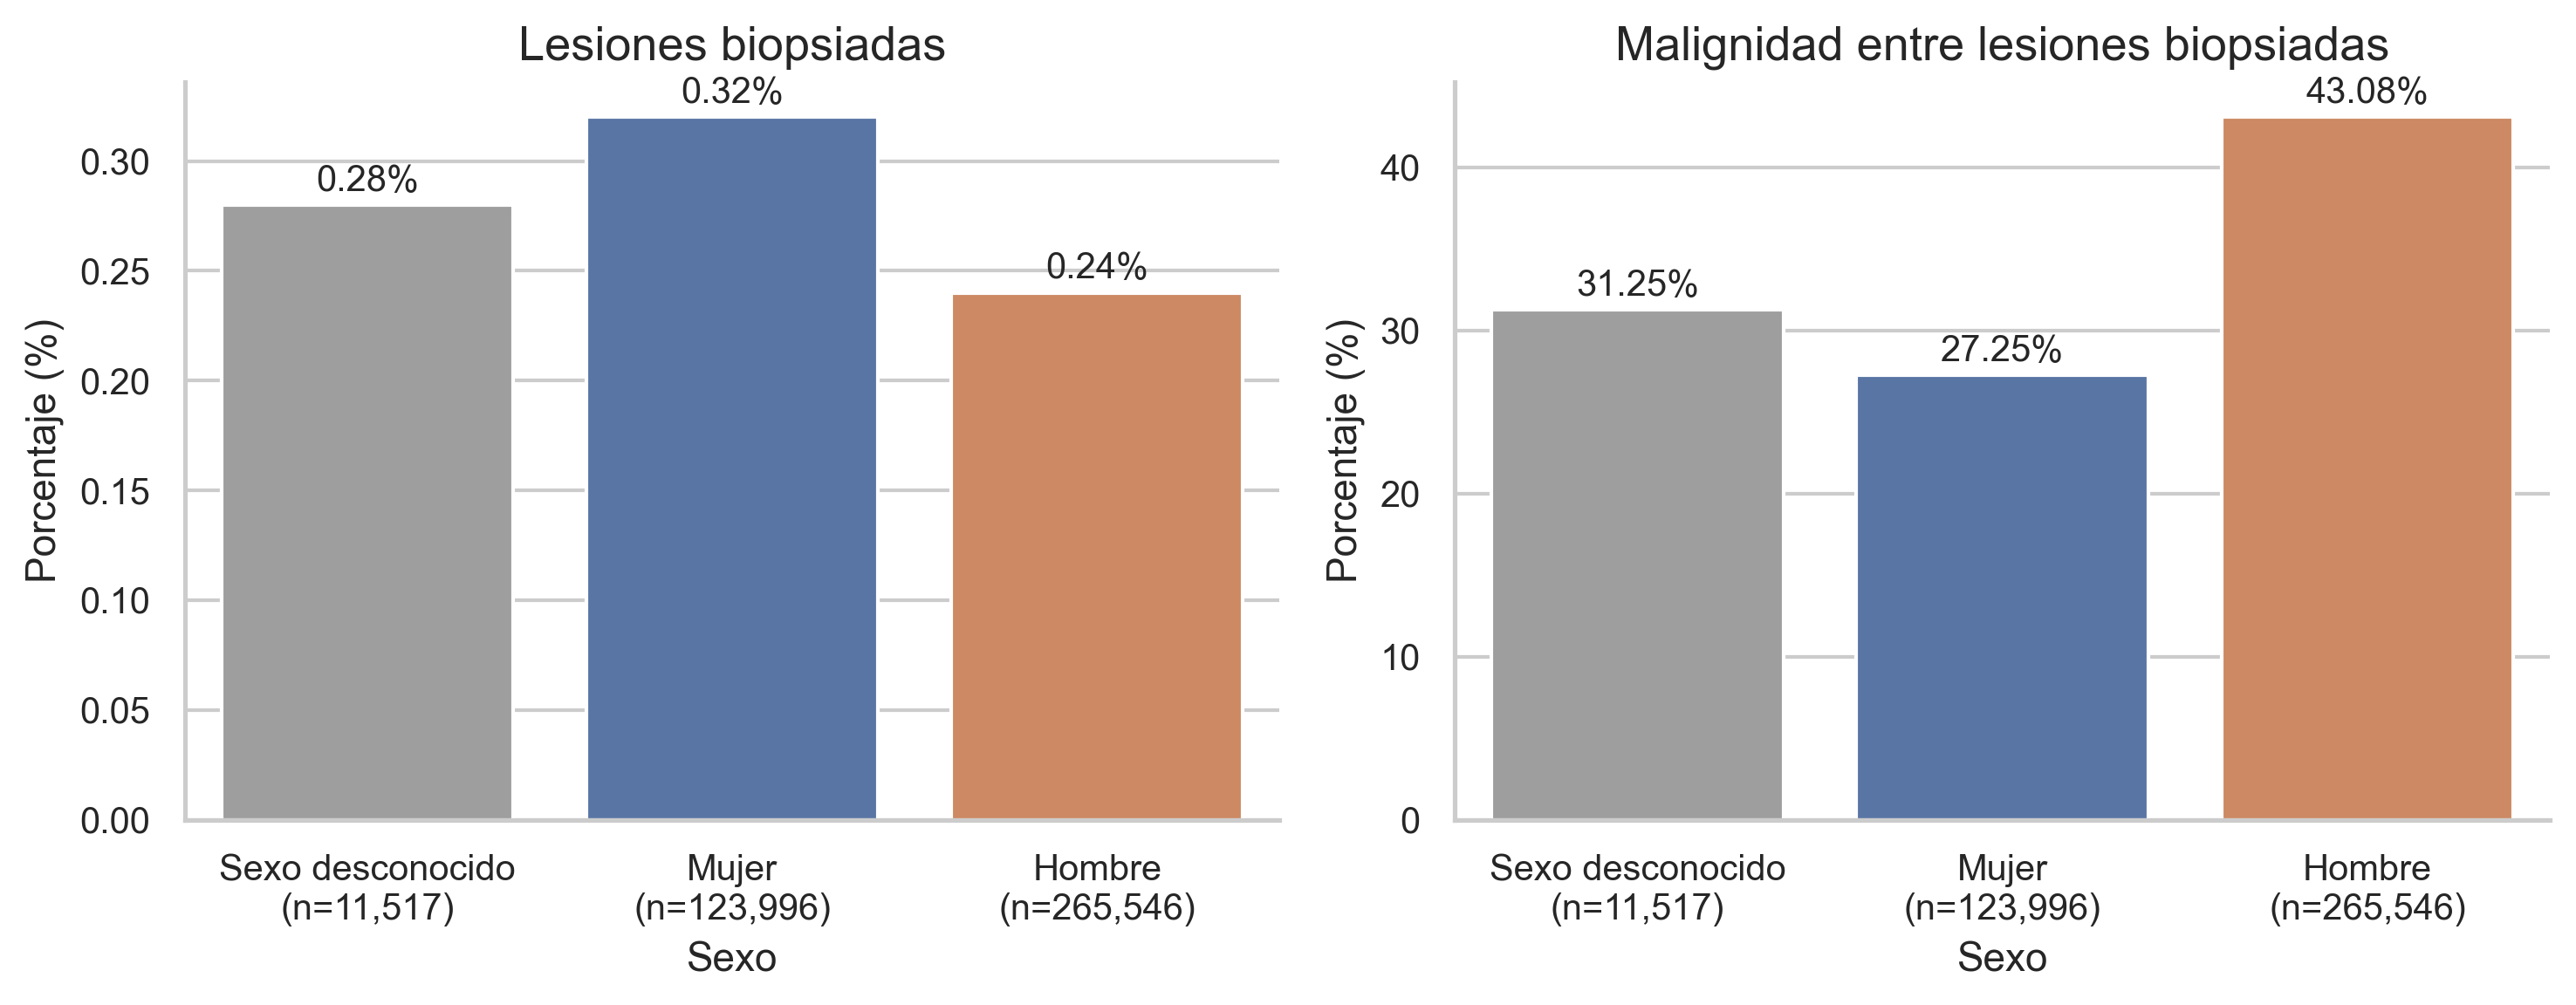

In [79]:
figures["sex_predictive_value"]

Para evaluar la asociación entre `sex` y las variables objetivo se emplean dos métricas complementarias. En primer lugar, se utiliza el test χ² de independencia para determinar si existe evidencia estadística de asociación entre las variables. Sin embargo, dado el elevado tamaño muestral disponible, pequeñas diferencias pueden resultar estadísticamente significativas aun careciendo de relevancia práctica. Por este motivo, la interpretación principal se basa en la V de Cramér, una medida de tamaño del efecto comprendida entre 0 y 1, donde valores próximos a 0 indican ausencia de asociación y valores crecientes reflejan asociaciones progresivamente más fuertes.

La asociación entre `sex` y la decisión de biopsiar una lesión resulta estadísticamente significativa, pero presenta una magnitud prácticamente nula (V de Cramér = 0.0074). Las proporciones de lesiones biopsiadas son muy similares entre mujeres (0.32%) y hombres (0.24%), lo que sugiere que el sexo aporta escasa información para discriminar entre lesiones biopsiadas y no biopsiadas.

Por el contrario, entre las lesiones ya biopsiadas se observa una asociación más marcada con la malignidad (V de Cramér = 0.1587). Las lesiones biopsiadas de pacientes masculinos presentan una proporción de malignidad sustancialmente superior a la observada en pacientes femeninos (43.08% frente a 27.25%), lo que sugiere que `sex` podría aportar información útil en modelos orientados a diferenciar lesiones malignas y no malignas.

Desde un punto de vista clínico, la literatura médica describe diferencias relevantes entre hombres y mujeres en la distribución anatómica de las lesiones cutáneas y de los tumores malignos. Por este motivo, aunque la asociación directa observada con algunas variables objetivo sea limitada, sex podría aportar información complementaria cuando se analiza conjuntamente con la localización de la lesión.

Respecto a los valores missing, estos afectan a 11,517 lesiones (2.87%) correspondientes a 33 pacientes (3.17%). La ausencia de información es completamente consistente a nivel de paciente: todos los pacientes afectados presentan la variable `sex` ausente en la totalidad de sus lesiones.

La distribución de los valores missing no es homogénea entre centros, sino que se concentra principalmente en el University Hospital of Basel y, en menor medida, en el Frazer Institute. Este patrón sugiere que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida, integración o anonimización de datos, más que con características clínicas propias de los pacientes o de las lesiones. Además, los pacientes con `sex` missing no presentan diferencias clínicamente relevantes en edad ni en distribución diagnóstica respecto al resto de la cohorte.

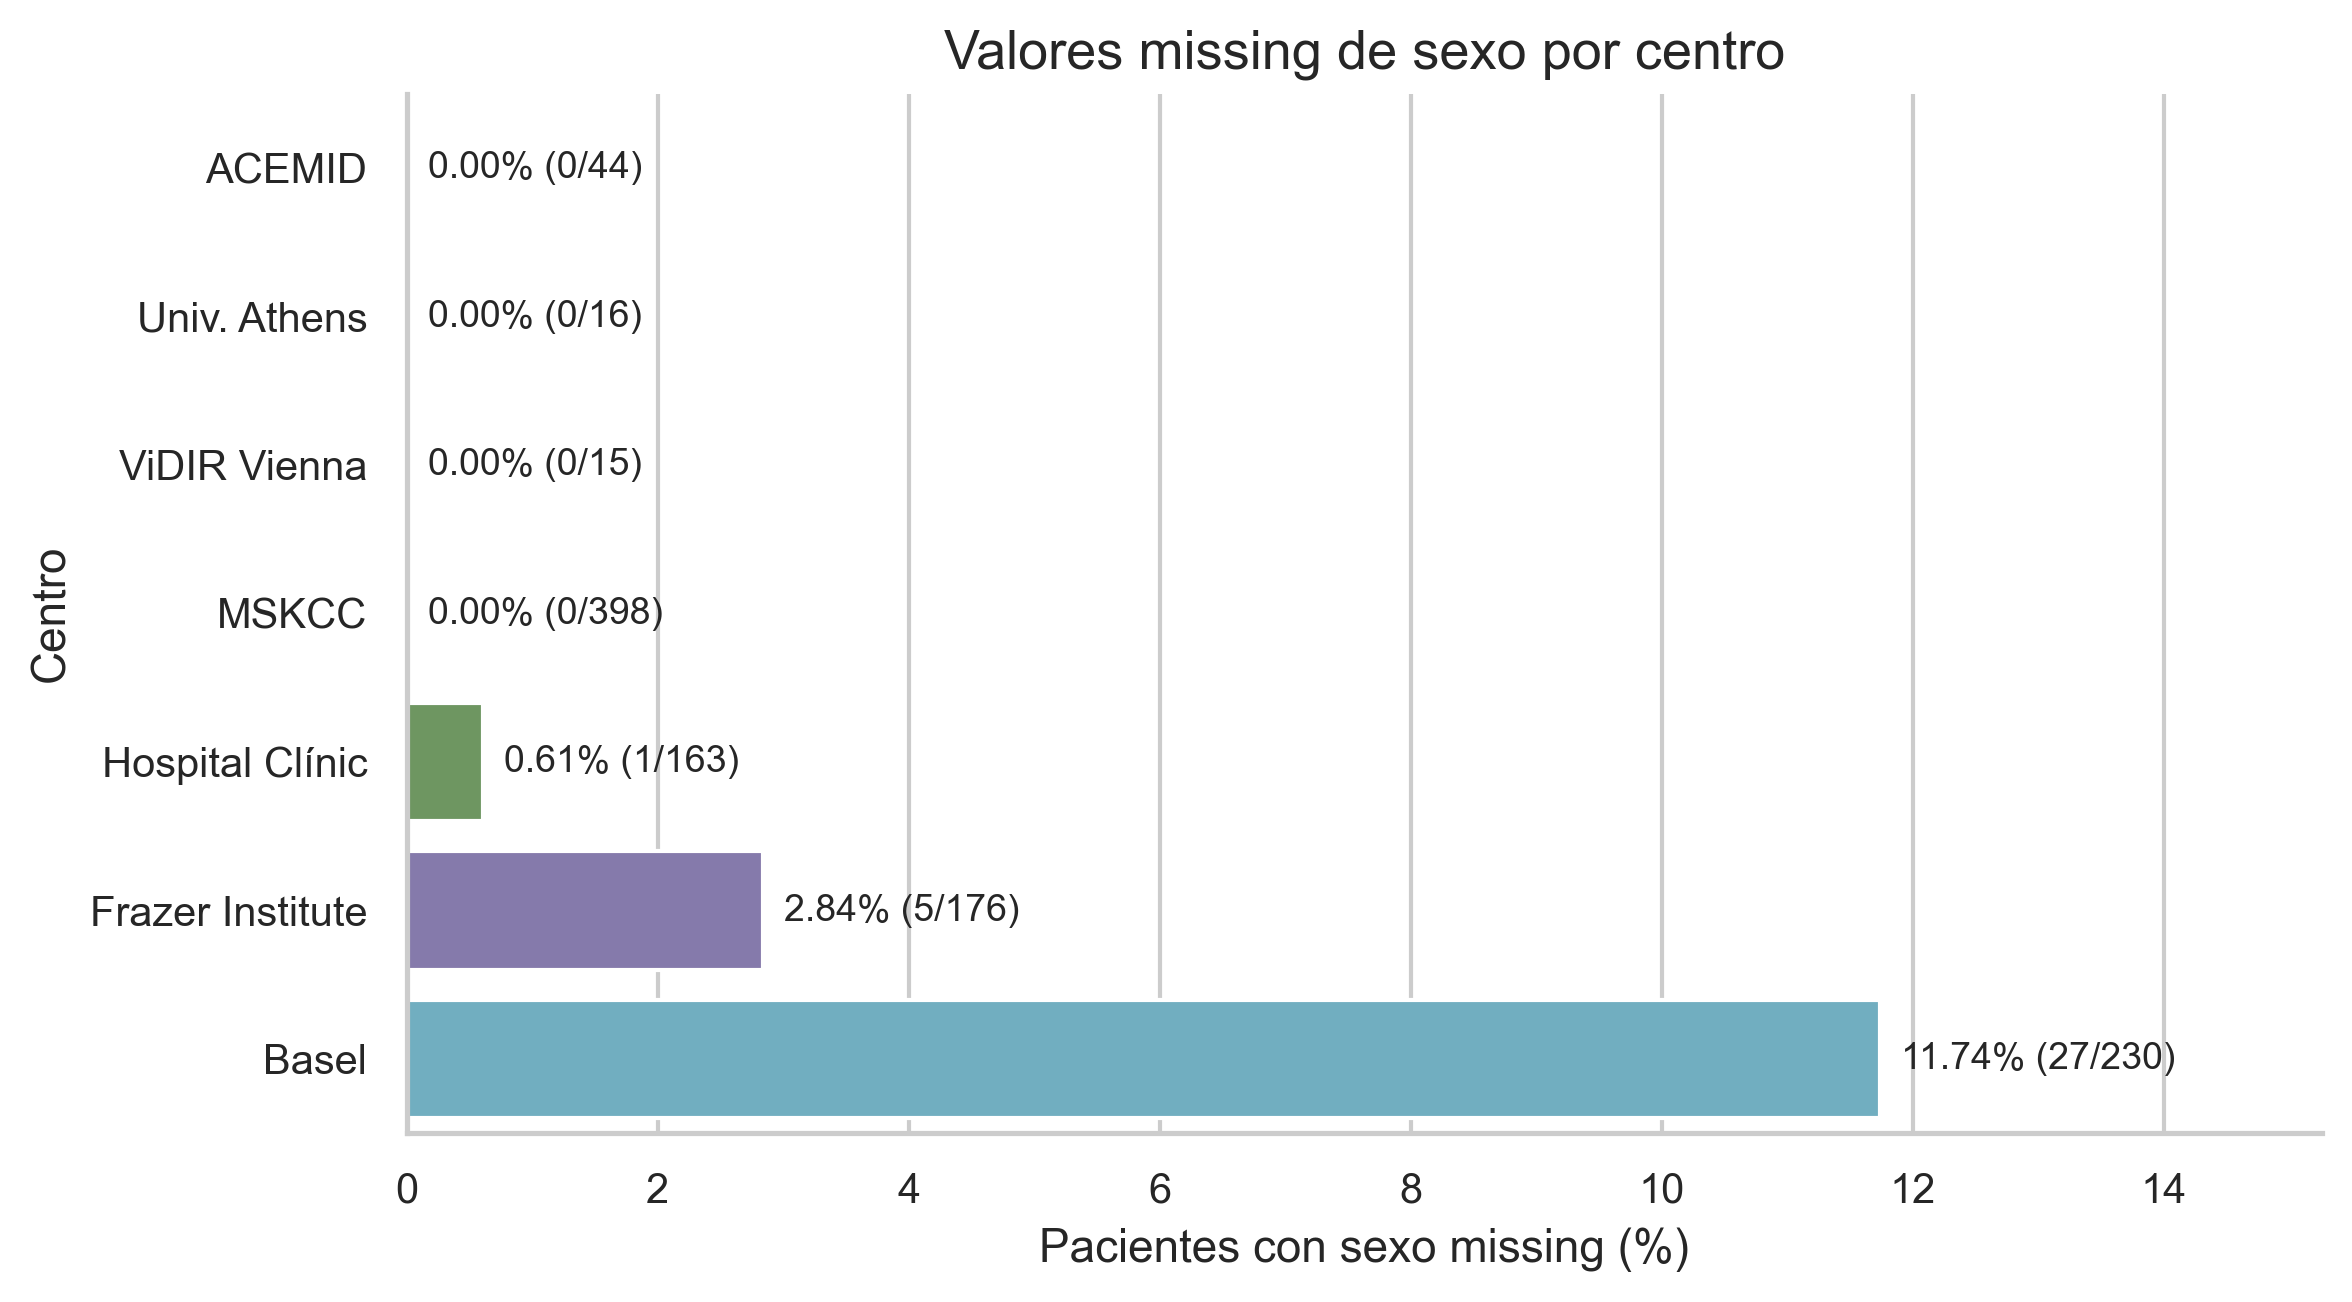

In [76]:
figures["sex_missing_attribution"]

En conjunto, la evidencia disponible sugiere que el mecanismo de ausencia es más compatible con un patrón Missing At Random (MAR) asociado al centro de procedencia (`attribution`) que con un mecanismo Missing Not At Random (MNAR). Bajo esta hipótesis, tanto la imputación como la eliminación de los pacientes afectados podrían considerarse estrategias de preprocesamiento. Sin embargo, dado el reducido porcentaje de valores missing, la ausencia de evidencias de sesgos clínicamente relevantes y el impacto potencialmente limitado de una imputación basada en un número reducido de variables disponibles, la eliminación de estos pacientes constituye una alternativa simple, siempre que no altere de forma apreciable la composición clínica del conjunto de datos.

Para evaluar el impacto potencial de esta decisión se compara la distribución global del dataset antes y después de eliminar los pacientes con valores missing en `sex`.

| Escenario                                 | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ----------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                          |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con `sex` missing |         1,009 |         96.83 |      389,542 |        97.13 |
| Registros eliminados                      |            33 |          3.17 |       11,517 |         2.87 |


| Categoría diagnóstica  | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | --------------: |
| Benign non-biopsied    |   99.7337 |     99.7340 |         +0.0003 |
| Benign biopsied        |    0.1399 |      0.1397 |         -0.0002 |
| Indeterminate biopsied |    0.0284 |      0.0280 |         -0.0004 |
| Malignant biopsied     |    0.0980 |      0.0983 |         +0.0003 |

Los cambios observados son inferiores a 0.0005 puntos porcentuales en todas las categorías diagnósticas analizadas, sin modificar de forma apreciable la composición clínica del conjunto de datos ni el grado de desbalanceo de las categorías de la variable objetivo. En consecuencia, se recomienda eliminar estos pacientes antes del entrenamiento de los modelos. Dado el reducido número de pacientes afectados y el impacto prácticamente nulo de su exclusión sobre la composición del conjunto de datos, esta estrategia evita introducir complejidad adicional mediante procedimientos de imputación, simplifica el tratamiento posterior de la variable y evita la creación de una categoría artificial (Unknown) con escasa representación y valor predictivo incierto.

Los pacientes a eliminar serían:

`IP_3371534`, `IP_6187331`, `IP_9472195`, `IP_2914511`, `IP_5044083`, `IP_6207479`, `IP_6975913`, `IP_1241473`, `IP_5887935`, `IP_8810058`, `IP_8999199`, `IP_6732258`, `IP_6413837`, `IP_1474479`, `IP_0797650`, `IP_2148283`, `IP_4579352`, `IP_7563441`, `IP_1715157`, `IP_1016097`, `IP_7703522`, `IP_4080836`, `IP_8377208`, `IP_1822913`, `IP_6193088`, `IP_0473747`, `IP_1433033`, `IP_6709102`, `IP_8036435`, `IP_2075317`, `IP_7858959`, `IP_9550509` e `IP_5373245`.

Finalmente, se recomienda codificarla mediante una representación binaria (`0/1`) para facilitar su utilización en los modelos de machine learning posteriores.

## Variable 'age_approx'

## Variable 'anatom_site_general'

## Variable 'clin_size_long_diam_mm'